# MDA Topic Modelling Pipeline (LDA)

**Pipeline steps:**
1. Load & reshape data
2. Build dictionary + corpus
3. Train initial LDA model
4. pyLDAvis visualisation
5. Perplexity evaluation
6. Coherence score
7. Grid search over number of topics
8. Evaluation plot (coherence + perplexity)
9. Select best model & assign dominant topic per sentence
10. Document-level topic distribution

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime

import gensim
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
import lda_preprocess

pyLDAvis.enable_notebook()
print('All imports successful.')

All imports successful.


## 1. Load & Preprocess Data

Reads the raw CSV and runs `lda_preprocess.docs2both`, which:
- Lemmatises and filters tokens via spaCy
- Builds a `CountVectorizer` DTM (for sklearn)
- Builds Gensim-style BoW vectors (for `LdaModel`)


In [2]:
import pandas as pd

df = pd.read_csv('../datasets/final/mda_shared_preprocessed.csv')

# Group sentences by filing → one document per filing
docs = (
    df.groupby(['doc_id', 'company_name', 'filing_type', 'filing_date', 'year', 'quarter'])
      ['sentence']
      .apply(' '.join)
      .reset_index()
      .rename(columns={'sentence': 'clean_text'})
)

docs.head()

,doc_id,company_name,filing_type,filing_date,year,quarter,clean_text
0,1-800-PetMeds_10-K_2020-05-26,1-800-PetMeds,10-K,2020-05-26,2020,Q2,approximately NUM of all sales were generated ...
1,1-800-PetMeds_10-K_2021-05-25,1-800-PetMeds,10-K,2021-05-25,2021,Q2,fiscal NUM started out with greater than expec...
2,1-800-PetMeds_10-K_2022-05-24,1-800-PetMeds,10-K,2022-05-24,2022,Q2,we have continued with working from home where...
3,1-800-PetMeds_10-K_2023-05-23,1-800-PetMeds,10-K,2023-05-23,2023,Q2,management does not believe that the resolutio...
4,1-800-PetMeds_10-K_2024-06-14,1-800-PetMeds,10-K,2024-06-14,2024,Q2,NUM we have direct buying relationships with a...


In [3]:
dtm, vectors, vectorizer = lda_preprocess.docs2both(docs)

In [4]:
print(docs.shape)

(17560, 8)


In [5]:
print(f'DTM shape: {dtm.shape}')   # (n_docs, vocab_size)
print(f'Corpus size: {len(vectors)} documents')

DTM shape: (17560, 10000)
Corpus size: 17560 documents


## 2. Build Dictionary & Corpus

In [6]:
# Derive token lists from the processed text produced by lda_preprocess
mda_docs = docs['processed_text'].str.split().tolist()

# Build Gensim Dictionary from actual token lists (needed for c_v coherence)
mda_dictionary = Dictionary(mda_docs)
print(f'Dictionary size before filtering: {len(mda_dictionary)}')

# Build Gensim BoW corpus from the dictionary (replaces the vectors from lda_preprocess)
mda_vecs = [mda_dictionary.doc2bow(doc) for doc in mda_docs]
print(f'Corpus size: {len(mda_vecs)} documents')

Dictionary size before filtering: 33470
Corpus size: 17560 documents


In [7]:
dict_df = pd.DataFrame([
    {'id': id, 'token': token, 'doc_freq': mda_dictionary.dfs[id], 'corpus_freq': mda_dictionary.cfs[id]}
    for id, token in mda_dictionary.items()
])
dict_df = dict_df.sort_values('corpus_freq', ascending=False)
print(dict_df.head(20))

      id      token  doc_freq  corpus_freq
408  408    revenue     12768        81678
56    56    expense     12776        64311
106  106    product     10115        57281
185  185    service     10285        55430
737  737      month     10386        51512
103  103  primarily     12747        45258
70    70   increase     11284        42042
31    31       cost     11066        41275
17    17       cash     10573        35989
132  132        tax      8221        34276
124  124       sale      9340        32924
217  217       base     10181        32571
82    82     market      8748        32564
317  317   interest      8611        28716
24    24    compare      8902        28433
177  177  operation      9404        27828
11    11      asset      7968        27189
184  184     result      9394        26028
442  442       term      9036        25651
206  206  agreement      7455        25132


## 3. Train Initial LDA Model

We train a first model with a chosen `num_topics` as a starting point. This is used for the pyLDAvis visualisation and quick evaluation before the grid search.

In [8]:
# CONFIG -----------------------------------------------------------------------
INIT_NUM_TOPICS = 20  # starting point -- will be optimised in grid search
PASSES          = 10  #number of times the model goes through the entire dataset during training
RANDOM_STATE    = 1

print(f'Training LDA with {INIT_NUM_TOPICS} topics...')
mda_lda = LdaModel(
    corpus=mda_vecs,
    id2word=mda_dictionary,
    num_topics=INIT_NUM_TOPICS,
    passes=PASSES,
    alpha="auto",      # learns document-topic prior from data
    eta="auto",        # learns topic-word prior from data
    random_state=RANDOM_STATE
)
print('Done.')

print('\nTop 5 words per topic:')
for i, topic in mda_lda.show_topics(num_topics=INIT_NUM_TOPICS, num_words=5, formatted=True):
    print(f'  Topic {i}: {topic}')

Training LDA with 20 topics...
Done.

Top 5 words per topic:
  Topic 0: 0.030*"health" + 0.022*"patient" + 0.021*"clinical" + 0.020*"care" + 0.017*"medicare"
  Topic 1: 0.031*"service" + 0.024*"device" + 0.022*"content" + 0.022*"mobile" + 0.021*"video"
  Topic 2: 0.012*"risk" + 0.011*"insurance" + 0.010*"market" + 0.009*"investment" + 0.009*"regulation"
  Topic 3: 0.046*"tax" + 0.015*"base" + 0.015*"revenue" + 0.015*"effective" + 0.013*"lease"
  Topic 4: 0.053*"patent" + 0.036*"license" + 0.032*"agreement" + 0.028*"court" + 0.019*"claim"
  Topic 5: 0.010*"product" + 0.009*"datum" + 0.009*"service" + 0.009*"security" + 0.008*"market"
  Topic 6: 0.091*"revenue" + 0.060*"service" + 0.038*"software" + 0.034*"subscription" + 0.024*"license"
  Topic 7: 0.082*"expense" + 0.038*"month" + 0.037*"cost" + 0.027*"cash" + 0.026*"primarily"
  Topic 8: 0.016*"expect" + 0.015*"pandemic" + 0.014*"cost" + 0.013*"impact" + 0.012*"operation"
  Topic 9: 0.038*"loan" + 0.038*"credit" + 0.035*"interest" + 0.

## 4. pyLDAvis Interactive Visualisation

In [9]:
print('Preparing pyLDAvis (may take a moment)...')
vis = gensimvis.prepare(mda_lda, mda_vecs, mda_dictionary)
vis

Preparing pyLDAvis (may take a moment)...


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
5     -0.080270  0.115388       1        1  12.740307
10     0.181075 -0.236419       2        1   9.158697
7      0.169558 -0.099298       3        1   8.646975
15     0.186258  0.049780       4        1   7.686995
9      0.202523  0.079417       5        1   7.181897
16     0.128192  0.179869       6        1   6.738499
3      0.142980  0.053879       7        1   5.615096
2      0.010583  0.169684       8        1   5.573439
17    -0.225104  0.020220       9        1   5.334900
6      0.039874 -0.134543      10        1   4.690094
8      0.039819 -0.023219      11        1   4.267338
13    -0.094593 -0.029500      12        1   4.185428
14     0.039237 -0.105726      13        1   4.069019
18    -0.098923 -0.159928      14        1   3.840699
1     -0.170156 -0.062210      15        1   2.378021
12    -0.059596 -0.075346      16        1   2.266519
0     -0.136621  0.123206      17        1   1.886527
19    -0.158635 -0.021888      18        1   1.791613
4     -0.004080  0.214920      19        1   1.396009
11    -0.112121 -0.058285      20        1   0.551930, topic_info=          Term          Freq         Total Category  logprob  loglift
408    revenue  81413.000000  81413.000000  Default  30.0000  30.0000
737      month  51053.000000  51053.000000  Default  29.0000  29.0000
56     expense  65650.000000  65650.000000  Default  28.0000  28.0000
106    product  57780.000000  57780.000000  Default  27.0000  27.0000
185    service  56206.000000  56206.000000  Default  26.0000  26.0000
...        ...           ...           ...      ...      ...      ...
88      online    299.435628   3823.674893  Topic20  -4.6932   2.6524
124       sale    451.087454  35491.107230  Topic20  -4.2835   0.8341
92       owner    186.189618   1003.792158  Topic20  -5.1684   3.5147
480   location    202.651242   2746.588349  Topic20  -5.0837   2.5929
1413   segment    231.014982  14930.786187  Topic20  -4.9527   1.0308

[1545 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
3531     20  0.928524      aap
191       1  0.524923  ability
191       3  0.017288  ability
191       4  0.020824  ability
191       5  0.080055  ability
...     ...       ...      ...
9048      2  0.952277     ying
4703     13  0.989303     zinc
3332      1  0.040034     zone
3332      8  0.818481     zone
3332      9  0.133448     zone

[7317 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[6, 11, 8, 16, 10, 17, 4, 3, 18, 7, 9, 14, 15, 19, 2, 13, 1, 20, 5, 12])

## 5. Perplexity (Initial Model)
**Lower is better.**

In [10]:
perplex = mda_lda.log_perplexity(mda_vecs)
print(f'Log Perplexity (initial model, {INIT_NUM_TOPICS} topics): {perplex:.4f}')

Log Perplexity (initial model, 20 topics): -7.7321


## 6. Coherence Score (Initial Model)

`c_v` coherence measures semantic similarity of top words within each topic. **Higher is better.**

In [11]:
coherence_model = CoherenceModel(
    model=mda_lda,
    texts=mda_docs,
    dictionary=mda_dictionary,
    coherence='c_v'
)
coherence_score = coherence_model.get_coherence()
print(f'Coherence Score c_v (initial model, {INIT_NUM_TOPICS} topics): {coherence_score:.4f}')
print('(Higher is better)')

Coherence Score c_v (initial model, 20 topics): 0.5576
(Higher is better)


## 7. Two-Phase Grid Search — Optimal Number of Topics

Both phases use Gensim LDA and track **coherence (c_v)** (primary) and **log perplexity** (secondary).

- **Phase 1 (Coarse):** Topics 5 → 40 in steps of 5. Identifies the best-coherence region.
- **Phase 2 (Fine):** Zooms into ±5 around the coarse best, in steps of 1.

> Runtime warning: each Gensim fit is slower than sklearn — expect several minutes per phase on large corpora.

In [12]:
# ── Phase 1: Coarse search (steps of 5, range 5–40) ──────────────────────────
COARSE_START = 10
COARSE_STOP  = 71   # inclusive of 70
COARSE_STEP  = 10
PASSES       = 10
RANDOM_STATE = 1

coarse_topics      = list(range(COARSE_START, COARSE_STOP, COARSE_STEP))
coarse_coherence   = []
coarse_perplexity  = []

print(f'Coarse search: {coarse_topics}')
print(f'Started: {datetime.datetime.now()}\n')

for n in coarse_topics:
    model = LdaModel(
        corpus=mda_vecs,
        id2word=mda_dictionary,
        num_topics=n,
        passes=PASSES,
        alpha='auto',
        eta='auto',
        random_state=RANDOM_STATE
    )
    cv   = CoherenceModel(model=model, texts=mda_docs,
                          dictionary=mda_dictionary, coherence='c_v').get_coherence()
    perp = model.log_perplexity(mda_vecs)
    coarse_coherence.append(cv)
    coarse_perplexity.append(perp)
    print(f'  n={n:>3} | Coherence (c_v): {cv:.4f} | Log Perplexity: {perp:.2f}')

print(f'\nFinished: {datetime.datetime.now()}')




Coarse search: [10, 20, 30, 40, 50, 60, 70]
Started: 2026-04-04 14:43:53.198794

  n= 10 | Coherence (c_v): 0.5447 | Log Perplexity: -7.31
  n= 20 | Coherence (c_v): 0.5576 | Log Perplexity: -7.73
  n= 30 | Coherence (c_v): 0.5605 | Log Perplexity: -8.05
  n= 40 | Coherence (c_v): 0.5568 | Log Perplexity: -8.40
  n= 50 | Coherence (c_v): 0.5528 | Log Perplexity: -8.73
  n= 60 | Coherence (c_v): 0.5458 | Log Perplexity: -9.08
  n= 70 | Coherence (c_v): 0.5366 | Log Perplexity: -9.45

Finished: 2026-04-04 15:18:26.662115



Best coarse: 30 topics (coherence=0.5605)
Fine search will zoom into: 25 – 35


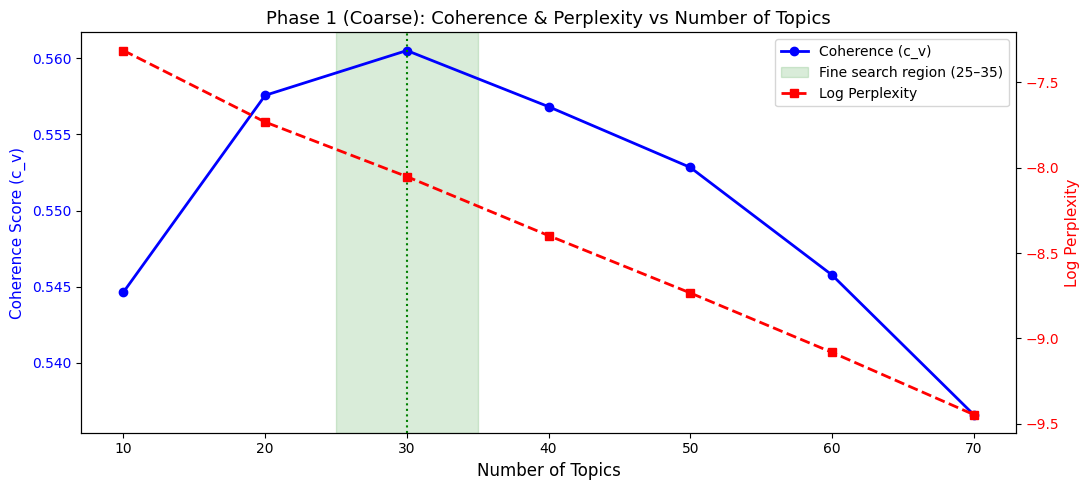

In [13]:
# ── Identify best coarse region ───────────────────────────────────────────────
best_coarse_idx = int(np.argmax(coarse_coherence))
best_coarse_n   = coarse_topics[best_coarse_idx]
fine_low        = best_coarse_n -5
fine_high       = best_coarse_n + 5
print(f'\nBest coarse: {best_coarse_n} topics (coherence={coarse_coherence[best_coarse_idx]:.4f})')
print(f'Fine search will zoom into: {fine_low} – {fine_high}')

# ── Plot Phase 1 ─────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax1.plot(coarse_topics, coarse_coherence,  'b-o', linewidth=2, markersize=6, label='Coherence (c_v)')
ax2.plot(coarse_topics, coarse_perplexity, 'r--s', linewidth=2, markersize=6, label='Log Perplexity')
ax1.axvspan(fine_low, fine_high, alpha=0.15, color='green', label=f'Fine search region ({fine_low}–{fine_high})')
ax1.axvline(x=best_coarse_n, color='green', linestyle=':', linewidth=1.5)

ax1.set_xlabel('Number of Topics', fontsize=12)
ax1.set_ylabel('Coherence Score (c_v)', color='b', fontsize=11)
ax2.set_ylabel('Log Perplexity', color='r', fontsize=11)
ax1.tick_params(axis='y', labelcolor='b')
ax2.tick_params(axis='y', labelcolor='r')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Phase 1 (Coarse): Coherence & Perplexity vs Number of Topics', fontsize=13)
plt.tight_layout()
plt.show()

In [14]:
# ── Phase 2: Fine search (step of 1, auto-range from coarse result) ──────────
fine_topics     = list(range(fine_low, fine_high + 1))
fine_coherence  = []
fine_perplexity = []
fine_models     = []

print(f'Fine search: {fine_topics}')
print(f'Started: {datetime.datetime.now()}\n')

for n in fine_topics:
    model = LdaModel(
        corpus=mda_vecs,
        id2word=mda_dictionary,
        num_topics=n,
        passes=PASSES,
        alpha='auto',
        eta='auto',
        random_state=RANDOM_STATE
    )
    cv   = CoherenceModel(model=model, texts=mda_docs,
                          dictionary=mda_dictionary, coherence='c_v').get_coherence()
    perp = model.log_perplexity(mda_vecs)
    fine_coherence.append(cv)
    fine_perplexity.append(perp)
    fine_models.append(model)
    print(f'  n={n:>3} | Coherence (c_v): {cv:.4f} | Log Perplexity: {perp:.2f}')

print(f'\nFinished: {datetime.datetime.now()}')

# ── Select best model ─────────────────────────────────────────────────────────
best_fine_idx = int(np.argmax(fine_coherence))
best_n        = fine_topics[best_fine_idx]
best_model    = fine_models[best_fine_idx]
print(f'\nOptimal number of topics: {best_n}')
print(f'  Coherence (c_v): {fine_coherence[best_fine_idx]:.4f}')
print(f'  Log Perplexity:  {fine_perplexity[best_fine_idx]:.2f}')




Fine search: [25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]
Started: 2026-04-04 15:18:27.098961

  n= 25 | Coherence (c_v): 0.5425 | Log Perplexity: -7.89
  n= 26 | Coherence (c_v): 0.5277 | Log Perplexity: -7.92
  n= 27 | Coherence (c_v): 0.5719 | Log Perplexity: -7.96
  n= 28 | Coherence (c_v): 0.5336 | Log Perplexity: -7.99
  n= 29 | Coherence (c_v): 0.5559 | Log Perplexity: -8.02
  n= 30 | Coherence (c_v): 0.5605 | Log Perplexity: -8.05
  n= 31 | Coherence (c_v): 0.5485 | Log Perplexity: -8.09
  n= 32 | Coherence (c_v): 0.5421 | Log Perplexity: -8.12
  n= 33 | Coherence (c_v): 0.5595 | Log Perplexity: -8.16
  n= 34 | Coherence (c_v): 0.5529 | Log Perplexity: -8.19
  n= 35 | Coherence (c_v): 0.5571 | Log Perplexity: -8.22

Finished: 2026-04-04 16:09:23.756732

Optimal number of topics: 27
  Coherence (c_v): 0.5719
  Log Perplexity:  -7.96


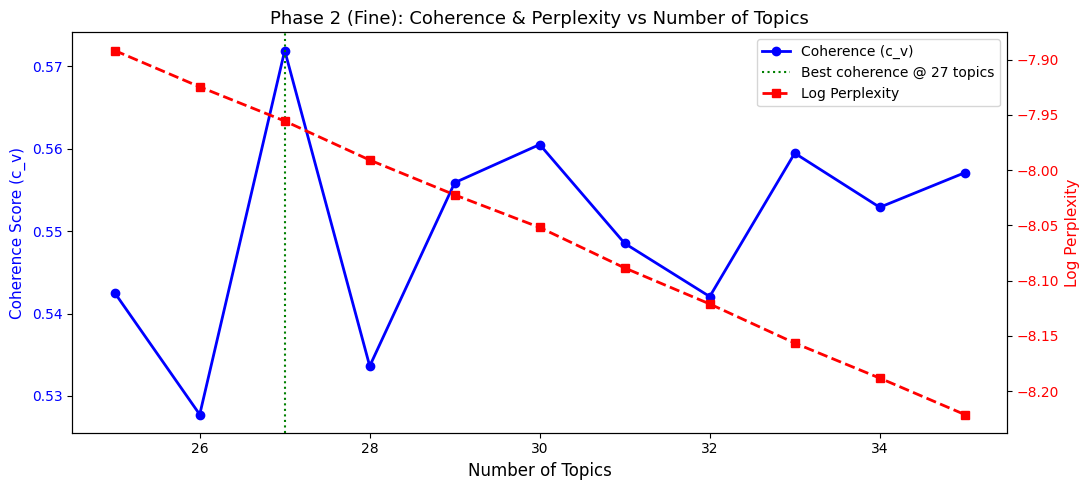

In [15]:
# ── Plot Phase 2 ─────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax1.plot(fine_topics, fine_coherence,  'b-o', linewidth=2, markersize=6, label='Coherence (c_v)')
ax2.plot(fine_topics, fine_perplexity, 'r--s', linewidth=2, markersize=6, label='Log Perplexity')
ax1.axvline(x=best_n, color='green', linestyle=':', linewidth=1.5,
            label=f'Best coherence @ {best_n} topics')

ax1.set_xlabel('Number of Topics', fontsize=12)
ax1.set_ylabel('Coherence Score (c_v)', color='b', fontsize=11)
ax2.set_ylabel('Log Perplexity', color='r', fontsize=11)
ax1.tick_params(axis='y', labelcolor='b')
ax2.tick_params(axis='y', labelcolor='r')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Phase 2 (Fine): Coherence & Perplexity vs Number of Topics', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Select Best Model 

Best model is selected automatically by highest `c_v` coherence.


In [16]:
print(f'Selected model: {best_n} topics')
print(f'  Coherence (c_v): {fine_coherence[best_fine_idx]:.4f}  (higher is better)')
print(f'  Log Perplexity:  {fine_perplexity[best_fine_idx]:.2f}  (lower is better)')

print(f'\nTop 10 words per topic:')
for i, topic in best_model.show_topics(num_topics=best_n, num_words=10, formatted=True):
    print(f'  Topic {i}: {topic}')

Selected model: 27 topics
  Coherence (c_v): 0.5719  (higher is better)
  Log Perplexity:  -7.96  (lower is better)

Top 10 words per topic:
  Topic 0: 0.036*"product" + 0.034*"clinical" + 0.024*"development" + 0.024*"trial" + 0.018*"drug" + 0.014*"research" + 0.013*"fda" + 0.012*"candidate" + 0.012*"program" + 0.011*"study"
  Topic 1: 0.031*"vehicle" + 0.022*"video" + 0.021*"product" + 0.020*"mobile" + 0.015*"smart" + 0.015*"display" + 0.014*"model" + 0.012*"automotive" + 0.011*"device" + 0.010*"sell"
  Topic 2: 0.028*"system" + 0.014*"energy" + 0.013*"laser" + 0.012*"market" + 0.011*"material" + 0.011*"process" + 0.010*"semiconductor" + 0.009*"application" + 0.009*"production" + 0.009*"advanced"
  Topic 3: 0.104*"cash" + 0.040*"capital" + 0.026*"flow" + 0.026*"activity" + 0.025*"operation" + 0.019*"financing" + 0.018*"liquidity" + 0.016*"term" + 0.015*"equivalent" + 0.015*"repurchase"
  Topic 4: 0.092*"apartment" + 0.006*"mil" + 0.000*"zillow" + 0.000*"trulia" + 0.000*"finder" + 0.00

In [17]:
print('Preparing pyLDAvis for best model (may take a moment)...')
vis = gensimvis.prepare(best_model, mda_vecs, mda_dictionary)
vis

Preparing pyLDAvis for best model (may take a moment)...


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
26     0.026073  0.110986       1        1  10.028870
5      0.181520 -0.004128       2        1   6.925304
15    -0.181746  0.078245       3        1   6.850252
10    -0.191159 -0.257596       4        1   6.702940
7     -0.162829 -0.102679       5        1   6.681199
21    -0.130372  0.194860       6        1   5.851047
9     -0.189897  0.117274       7        1   4.894546
6     -0.068905 -0.141743       8        1   4.398244
25     0.070758  0.150490       9        1   4.095416
3     -0.183414  0.067410      10        1   4.007889
18    -0.076272 -0.196280      11        1   3.963770
24    -0.087474  0.078167      12        1   3.758382
17     0.225162 -0.066636      13        1   3.450068
22    -0.136151  0.090193      14        1   3.225963
20     0.100147  0.095515      15        1   3.153348
14    -0.046695 -0.174564      16        1   3.120182
12     0.065634 -0.066590      17        1   2.921838
13     0.019093 -0.021894      18        1   2.673615
19    -0.098836  0.085364      19        1   2.129188
8      0.032929 -0.076026      20        1   2.087458
23     0.069655 -0.210137      21        1   2.070927
2      0.177060  0.013823      22        1   1.721620
16    -0.016856  0.080572      23        1   1.707797
1      0.202975 -0.073946      24        1   1.509064
0      0.143551  0.093407      25        1   1.037505
11     0.095422  0.058002      26        1   1.028339
4      0.160627  0.077912      27        1   0.005231, topic_info=           Term          Freq         Total Category  logprob  loglift
737       month  51572.000000  51572.000000  Default  30.0000  30.0000
408     revenue  82065.000000  82065.000000  Default  29.0000  29.0000
56      expense  65275.000000  65275.000000  Default  28.0000  28.0000
106     product  59174.000000  59174.000000  Default  27.0000  27.0000
17         cash  37564.000000  37564.000000  Default  26.0000  26.0000
..          ...           ...           ...      ...      ...      ...
20     commerce      0.008347    908.110319  Topic27 -10.5221  -1.7389
21   commitment      0.008347   5348.370559  Topic27 -10.5221  -3.5120
22      company      0.008347  11918.239160  Topic27 -10.5221  -4.3133
23     companys      0.008347   5087.146870  Topic27 -10.5221  -3.4620
24      compare      0.008347  30345.598608  Topic27 -10.5221  -5.2479

[2035 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
3531     26  0.902172      aap
191       1  0.592699  ability
191       2  0.098799  ability
191       3  0.014541  ability
191       5  0.003756  ability
...     ...       ...      ...
1473     22  0.123174    yield
7074     17  0.986489  youtube
4703     16  0.978353     zinc
6479     13  0.003921     zoom
6479     15  0.991978     zoom

[10692 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[27, 6, 16, 11, 8, 22, 10, 7, 26, 4, 19, 25, 18, 23, 21, 15, 13, 14, 20, 9, 24, 3, 17, 2, 1, 12, 5])

In [18]:
# Step 1: Get topic distribution for each filing
def get_dominant_topic_per_filing(ldamodel, corpus, docs_df):
    """
    For each filing, find its dominant topic, contribution %, and top keywords.
    corpus and docs_df must be in the same order.
    """
    rows = []
    for i, row_dist in enumerate(ldamodel[corpus]):
        row_dist = sorted(row_dist, key=lambda x: x[1], reverse=True)
        if not row_dist:
            continue
        topic_num, prop_topic = row_dist[0]
        wp             = ldamodel.show_topic(topic_num, topn=5)
        topic_keywords = ', '.join([word for word, _ in wp])
        rows.append({
            'doc_id':             docs_df.iloc[i]['doc_id'],
            'company_name':       docs_df.iloc[i]['company_name'],
            'filing_type':        docs_df.iloc[i]['filing_type'],
            'filing_date':        docs_df.iloc[i]['filing_date'],
            'year':               docs_df.iloc[i]['year'],
            'quarter':            docs_df.iloc[i]['quarter'],
            'Dominant_Topic':     int(topic_num),
            'Topic_Perc_Contrib': round(prop_topic, 4),
            'Topic_Keywords':     topic_keywords,
        })
    return pd.DataFrame(rows)

df_filing_topics = get_dominant_topic_per_filing(best_model, mda_vecs, docs)
print(f'Assigned dominant topics to {len(df_filing_topics)} filings.')
df_filing_topics.head(5)

Assigned dominant topics to 17560 filings.


,doc_id,company_name,filing_type,filing_date,year,quarter,Dominant_Topic,Topic_Perc_Contrib,Topic_Keywords
0,1-800-PetMeds_10-K_2020-05-26,1-800-PetMeds,10-K,2020-05-26,2020,Q2,12,0.2246,"advertising, revenue, content, marketing, cons..."
1,1-800-PetMeds_10-K_2021-05-25,1-800-PetMeds,10-K,2021-05-25,2021,Q2,14,0.2529,"sale, product, price, inventory, cost"
2,1-800-PetMeds_10-K_2022-05-24,1-800-PetMeds,10-K,2022-05-24,2022,Q2,10,0.2687,"month, compare, revenue, increase, primarily"
3,1-800-PetMeds_10-K_2023-05-23,1-800-PetMeds,10-K,2023-05-23,2023,Q2,26,0.3274,"market, product, result, ability, affect"
4,1-800-PetMeds_10-K_2024-06-14,1-800-PetMeds,10-K,2024-06-14,2024,Q2,25,0.4554,"law, security, datum, regulation, risk"


## 9. Document-Level Topic Distribution

Aggregates sentence-level assignments to show which topics dominate each filing.

In [19]:
# Step 2: Full topic distribution per filing (all topic probabilities, not just dominant)
def get_full_topic_dist(ldamodel, corpus, docs_df):
    """
    Returns a DataFrame where each column is a topic and each row is a filing.
    Values are the probability of that topic for the filing.
    """
    n_topics = ldamodel.num_topics
    rows = []
    for i, row_dist in enumerate(ldamodel[corpus]):
        topic_probs = dict(row_dist)
        row = {f'Topic_{t}': round(topic_probs.get(t, 0.0), 4) for t in range(n_topics)}
        row['doc_id'] = docs_df.iloc[i]['doc_id']
        rows.append(row)
    df = pd.DataFrame(rows).set_index('doc_id')
    return df

df_full_dist = get_full_topic_dist(best_model, mda_vecs, docs)
df_full_dist.head(5)

,Topic_0,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8,Topic_9,...,Topic_17,Topic_18,Topic_19,Topic_20,Topic_21,Topic_22,Topic_23,Topic_24,Topic_25,Topic_26
doc_id,,,,,,,,,,,,,,,,,,,,,
1-800-PetMeds_10-K_2020-05-26,0.0000,0.0000,0.0,0.1153,0.0,0.0000,0.0,0.0777,0.0927,0.0,...,0.0,0.0,0.0,0.0675,0.0,0.0000,0.0000,0.0221,0.0000,0.0000
1-800-PetMeds_10-K_2021-05-25,0.0289,0.0000,0.0,0.0395,0.0,0.0000,0.0,0.0000,0.1941,0.0,...,0.0,0.0,0.0,0.0000,0.0,0.0000,0.0999,0.0000,0.0000,0.0000
1-800-PetMeds_10-K_2022-05-24,0.0000,0.0157,0.0,0.1417,0.0,0.0000,0.0,0.0000,0.0000,0.0,...,0.0,0.0,0.0,0.1302,0.0,0.0148,0.0000,0.1290,0.0000,0.0000
1-800-PetMeds_10-K_2023-05-23,0.0110,0.0000,0.0,0.0000,0.0,0.0223,0.0,0.0000,0.0570,0.0,...,0.0,0.0,0.0,0.0000,0.0,0.0000,0.0375,0.0000,0.3259,0.3274
1-800-PetMeds_10-K_2024-06-14,0.0243,0.0663,0.0,0.0000,0.0,0.0000,0.0,0.0000,0.0592,0.0,...,0.0,0.0,0.0,0.0000,0.0,0.0000,0.0000,0.0000,0.4550,0.2429
